In [2]:
import LemonPy.LFP.lfp_analysis as LFP
import LemonPy.Units.unit_analysis as UNITS

from IPython.display import display
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import LemonPy.LFP.mz_LFP_functions as mz_LFP
plt.rcParams['pdf.fonttype'] = 42

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA as sklearnPCA
def unit_kmeans(data, n, key, t0, t1):
    tmp_ls = []
    for (region, stim), tmp in data.groupby(['region', 'stim_id']):
        df_new = tmp.pivot(index='times', columns='cuid', values='zscore')
    
        df_new = df_new.reset_index()
        df_new = df_new.drop('times',axis = 1)
        df_new = df_new.T
        
        X = df_new.iloc[:,t0:t1].values #0.5-2 second interval
        y = df_new.index.values.tolist() # corresponding cuid
        
        sklearn_pca = sklearnPCA(n_components=n)
        Y_sklearn = sklearn_pca.fit_transform(X)
        pca = sklearn_pca.fit(X)
        
        model = KMeans(init=pca.components_, n_clusters=n, n_init=1)
        
        model.fit(X)
        y_kmeans = model.predict(X)
        
        unique_id = df_new.index.values
        d = map_cluster(y_kmeans, unique_id)
        tmp[str(key)] = tmp['cuid'].map(d)
        tmp.describe()

        groups = tmp[str(key)].unique()

        # store mean_zscores for each group
        mean_zscores = {}
        for g in groups:
            mean_zscores[g] = (
                tmp[(tmp[str(key)] == g) & (tmp.times > t0/100) & (tmp.times < t1/100)]
                .groupby("cuid").zscore.max().mean()
            )
        
        sorted_groups = sorted(mean_zscores, key=mean_zscores.get, reverse=True)
        rank_map = {g: i for i, g in enumerate(sorted_groups)}
        
        # assign rank to each row
        tmp[key] = tmp[str(key)].map(rank_map)
            
        tmp_ls.append(tmp)

    tmp_ls = pd.concat(tmp_ls)
    return tmp_ls
    
def map_cluster(y_kmeans, n):
    ls = list(y_kmeans)
    d = {}
    j = int(0)
    for i in n:
        d[i]=ls[j]
        j = int(j + 1)
    return d

In [4]:
from LemonPy.Units.detect_peaks import detect_peaks
from LemonPy.Units import mz_ephys_unit_analysis as mz_ena
from LemonPy.Units import mz_unit_dur_freq as mz_udf

def get_strong_unit(psth_df):
    print("No. of mice: ", psth_df.et.nunique())
    print("Groups: ", psth_df.group.unique())
    print("Brain regions: ",psth_df.region.unique())

    V1_all_groups_situ = psth_df

    df_strong_list=[]
    for group in V1_all_groups_situ.group.unique():
        temp_arr = V1_all_groups_situ[(V1_all_groups_situ['group'] == group)] 
        duration = []
        ind = []
        unit_region = []
        cuid=[]
        for unit, df in temp_arr.groupby('cuid'):
            yy = np.array(df.zscore)
            peak_ind = detect_peaks(yy, mph=1.5, mpd=5, show = False, edge='both') #default mph=1.5
            if len(peak_ind) > 2 and peak_ind[0]>=50: # Strong Unit: Units have more that 2 peaks
                ind.append(peak_ind)
                cuid.append(unit)
                unit_region.append(df.region.unique()[0])
        temp_df_strong = temp_arr[temp_arr['cuid'].isin(cuid)]
        df_strong_list.append(temp_df_strong)
    df_strong=pd.concat(df_strong_list)
    return df_strong

## dataset

In [5]:
df_tmt_fam=pd.read_pickle(r"U:\Data_Analysis\yin268\LemonPy analysis\MZ_FXbehavior_data\operant_waveforms_df.pkl")
df_tmt_novel=pd.read_pickle(r"U:\Data_Analysis\yin268\LemonPy analysis\MZ_FXbehavior_data\novel_waveforms_df.pkl")

psth_df_fam=pd.read_pickle(r"U:\Data_Analysis\yin268\LemonPy analysis\MZ_FXbehavior_data\operant_1sec_psth_v3.pkl")
psth_df_novel=pd.read_pickle(r"U:\Data_Analysis\yin268\LemonPy analysis\MZ_FXbehavior_data\novel_1sec_psth.pkl")

In [7]:
psth_df_fam_strong=get_strong_unit(psth_df_fam)
psth_df_novel_strong=get_strong_unit(psth_df_novel)

No. of mice:  18
Groups:  ['B' 'A']
Brain regions:  ['none' 'thal' 'v1' 'hippo']
No. of mice:  16
Groups:  ['B' 'A']
Brain regions:  ['thal' 'v1' 'hippo' 'none']


In [32]:
psth_df_fam_strong.to_pickle(r"U:\Data_Analysis\yin268\LemonPy analysis\MZ_FXbehavior_data\strong_operant_1sec_psth.pkl")
psth_df_novel_strong.to_pickle(r"U:\Data_Analysis\yin268\LemonPy analysis\MZ_FXbehavior_data\strong_novel_1sec_psth.pkl")

In [14]:
psth_df_fam=pd.read_pickle(r"U:\Data_Analysis\yin268\LemonPy analysis\MZ_FXbehavior_data\strong_operant_1sec_psth.pkl")

In [15]:
psth_df_fam_v1=psth_df_fam[psth_df_fam['region'] == 'v1']
psth_df_fam_hpc=psth_df_fam[psth_df_fam['region'] == 'hippo']

In [16]:
df_tmt_fam_v1=df_tmt_fam[df_tmt_fam['region'] == 'v1']
df_tmt_fam_hpc=df_tmt_fam[df_tmt_fam['region'] == 'hippo']

In [17]:
psth_df_fam_v1 = unit_kmeans(psth_df_fam_v1, 2, 'vis_res', 50, 70) 
psth_df_fam_hpc = unit_kmeans(psth_df_fam_hpc, 2, 'vis_res', 50, 70) 

In [18]:
#WT
psth_df_fam_v1[psth_df_fam_v1['group']=='A'].et.nunique()

10

In [19]:
#FX
psth_df_fam_v1[psth_df_fam_v1['group']=='B'].et.nunique()

8

### v1


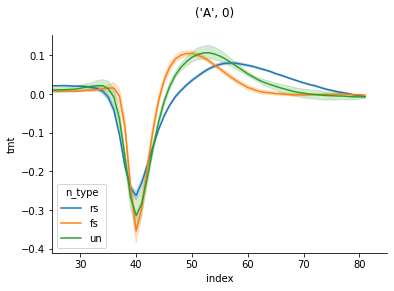

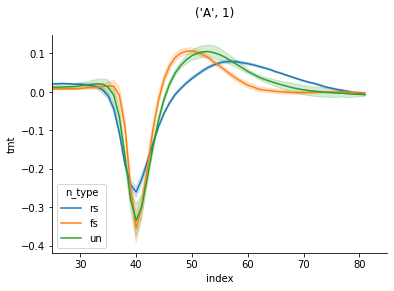

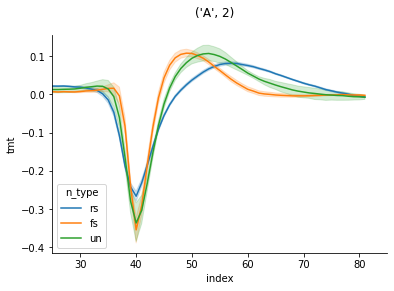

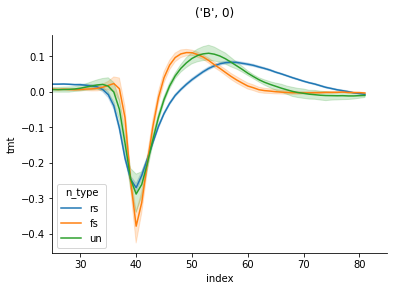

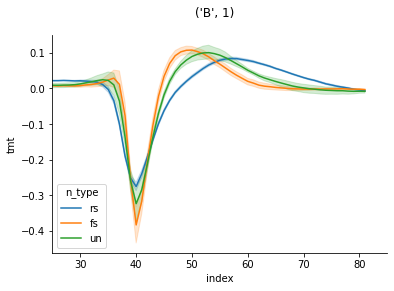

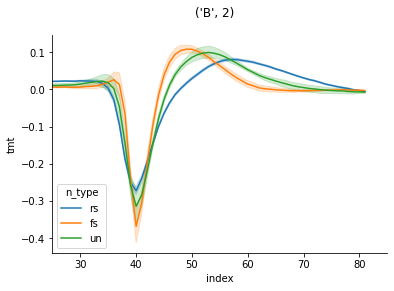

In [20]:
#Plot the average waveforms of FS/RS neurons
psth_df = psth_df_fam_v1[psth_df_fam_v1['vis_res']==0]
df_tmt = df_tmt_fam_v1
for t, tt in df_tmt.groupby(['group','stim_id']):
    #for visually responsive true unit only
    group = t[0]
    stim_id = t[1]
    psth_df_tmp = psth_df[(psth_df['group']==group) & (psth_df['stim_id']==stim_id)]
    ls_cuid = psth_df_tmp.cuid.unique()
    df_tmt_final = tt[tt['cuid'].isin(ls_cuid)]
    
    tmp = df_tmt_final.reset_index()
    sns.lineplot(
        data=tmp,
        x='index',
        y='tmt',
        hue='n_type',
        hue_order=['rs','fs','un']
        #units='cuid'
    )
    
    sns.despine()
    plt.xlim(25,85)
    #plt.ylim(-6.5,3)
    plt.suptitle(f'{t}')
    #plt.savefig(f"U:/Data_Analysis/yin268/LemonPy analysis/MZ_FXbehavior_data/figure/strong/V1_{t}_rsfs_waveform.pdf", transparent=True)
    plt.show()

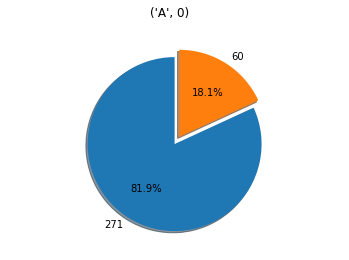

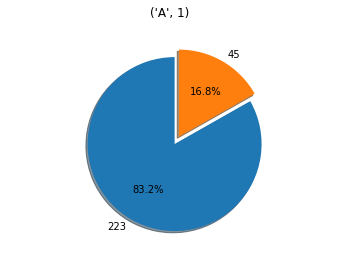

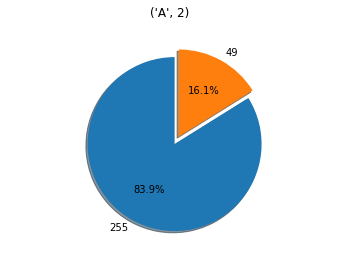

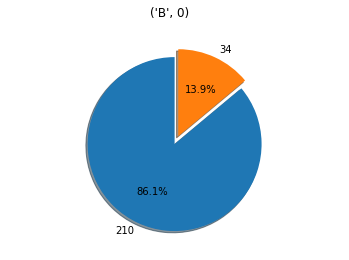

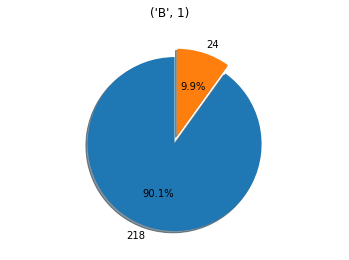

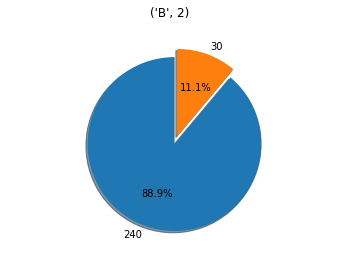

In [21]:
#pie plot for FS/RS neurons
psth_df = psth_df_fam_v1[psth_df_fam_v1['vis_res']==0]
df_tmt = df_tmt_fam_v1

for t, tt in df_tmt.groupby(['group','stim_id']):
    #for visually responsive true unit only
    group = t[0]
    stim_id = t[1]
    psth_df_tmp = psth_df[(psth_df['group']==group) & (psth_df['stim_id']==stim_id)]
    ls_cuid = psth_df_tmp.cuid.unique()
    df_tmt_final = tt[tt['cuid'].isin(ls_cuid)]

    count = len(df_tmt_final.cuid.unique())
    count_fs = len(df_tmt_final[(df_tmt_final.n_type=='fs')].cuid.unique())
    percent_fs = (count_fs / count) * 100
    count_rs = len(df_tmt_final[(df_tmt_final.n_type=='rs')].cuid.unique())
    percent_rs = (count_rs / count) * 100
    

    labels = str(count_rs), str(count_fs)
    
    sizes = [percent_rs, percent_fs]
    explode = (0, 0.1)  #0.1 if you want to "pop out" one of the pieces
    plt.axis('equal')
    plt.pie(sizes, explode=explode, labels=labels, 
            autopct='%1.1f%%', shadow=True, startangle=90)
    plt.suptitle(f'{t}')
    #plt.savefig(f"U:/Data_Analysis/yin268/LemonPy analysis/MZ_FXbehavior_data/figure/strong/V1_{t}_rsfs_piechart.pdf", transparent=True)
    plt.show()


In [22]:
#pie plot for FS/RS neurons
psth_df = psth_df_fam_v1[psth_df_fam_v1['vis_res']==0]
df_tmt = df_tmt_fam_v1

summary = []

for t, tt in df_tmt.groupby(['group','stim_id','et']):
    #for visually responsive true unit only
    group = t[0]
    stim_id = t[1]
    et = t[2]
    psth_df_tmp = psth_df[(psth_df['group']==group) & (psth_df['stim_id']==stim_id)& (psth_df['et']==et)]
    ls_cuid = psth_df_tmp.cuid.unique()
    df_tmt_final = tt[tt['cuid'].isin(ls_cuid)]

    count = len(df_tmt_final.cuid.unique())
    count_fs = len(df_tmt_final[(df_tmt_final.n_type=='fs')].cuid.unique())
    percent_fs = (count_fs / count) * 100
    count_rs = len(df_tmt_final[(df_tmt_final.n_type=='rs')].cuid.unique())
    percent_rs = (count_rs / count) * 100
    
    summary.append({
        'group': group,
        'et':et,
        'stim_id': stim_id,
        'count_total': count_fs+count_rs,
        'count_fs': count_fs,
        'count_rs': count_rs,
        'percent_fs': percent_fs,
        'percent_rs': percent_rs
    })
    df_summary = pd.DataFrame(summary)
    

In [23]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
    
df_summary = df_summary.dropna(subset=['percent_fs'])  # Drop NaN rows if any

# LMM model: percent_fs ~ group + (1|et)
model = mixedlm("percent_fs ~ group", df_summary, groups=df_summary["stim_id"])
result = model.fit()
print(result.summary())


C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: percent_fs
No. Observations: 54      Method:             REML      
No. Groups:       3       Scale:              57.0909   
Min. group size:  18      Log-Likelihood:     -182.2716 
Max. group size:  18      Converged:          No        
Mean group size:  18.0                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     16.036    1.394 11.507 0.000 13.305 18.768
group[T.B]    -5.385    2.069 -2.602 0.009 -9.441 -1.329
Group Var      0.118    0.729                           



C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 0.492416
  warnings.warn(msg, ConvergenceWarning)


In [24]:
for stim_id in df_summary.stim_id.unique():
    df_each=df_summary[df_summary['stim_id']==stim_id]
    stat, p_normal = shapiro(df_each.percent_fs)
    print(f"Shapiro-Wilk test p = {p_normal:.4f}")
    
    # if p_normal > 0.05:
    #     print("percentage are normal → use t-test")
    # else:
    #     print("percentage are not normal → use Mann–Whitney U")

Shapiro-Wilk test p = 0.4803
Shapiro-Wilk test p = 0.0055
Shapiro-Wilk test p = 0.0065


In [25]:
for stim_id in df_summary.stim_id.unique():
    df_each=df_summary[df_summary['stim_id']==stim_id]
    group_names = df_each['group'].unique()
    g1, g2 = group_names
    data1 = df_each[df_each['group'] == g1]['percent_fs']
    data2 = df_each[df_each['group'] == g2]['percent_fs']
    
    stat, pval = mannwhitneyu(data1, data2, alternative='two-sided')
    print(f"\nMann–Whitney U between {g1} and {g2} for {stim_id}: U = {stat:.3f}, p = {pval:.4f}")



Mann–Whitney U between A and B for 0: U = 53.000, p = 0.2665

Mann–Whitney U between A and B for 1: U = 58.500, p = 0.1096

Mann–Whitney U between A and B for 2: U = 55.500, p = 0.1824


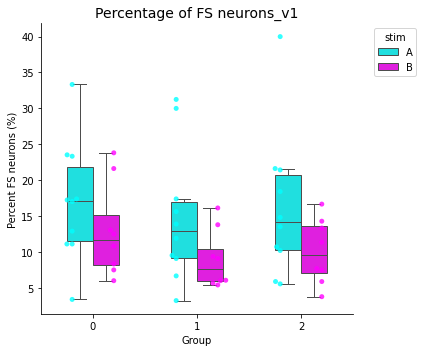

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

palette = {"A": "cyan", "B": "magenta"}

plt.figure(figsize=(6,5))
sns.boxplot(data=df_summary, x='stim_id', y='percent_fs', hue='group',
            width=0.5, fliersize=0,     palette=palette)
sns.swarmplot(data=df_summary, x='stim_id', y='percent_fs',
              hue='group', dodge=True, size=5, alpha=0.8, palette=palette,legend=False)

plt.title("Percentage of FS neurons_v1", fontsize=14)
plt.ylabel("Percent FS neurons (%)")
plt.xlabel("Group")
plt.legend(title='stim', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
#plt.savefig(f"U:/Data_Analysis/yin268/LemonPy analysis/MZ_FXbehavior_data/figure/strong/v1_rsfs_quantification.pdf", transparent=True)
plt.show()

### hpc

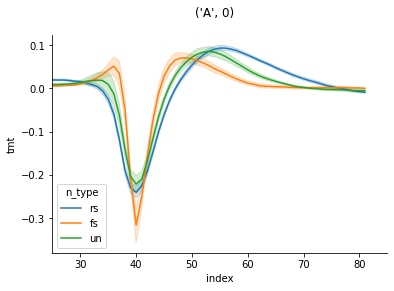

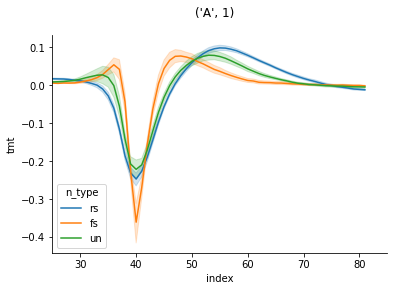

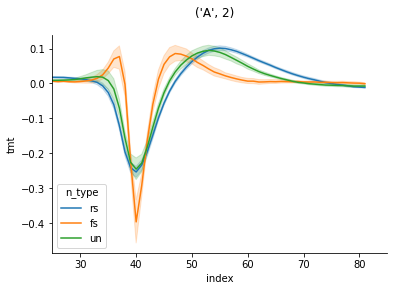

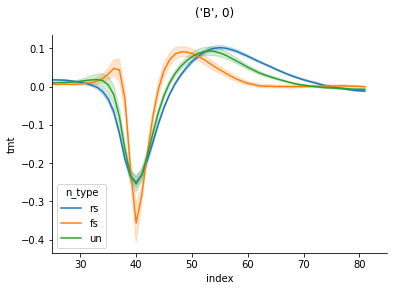

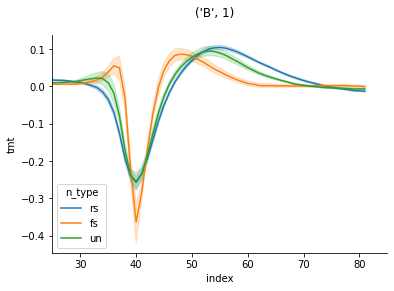

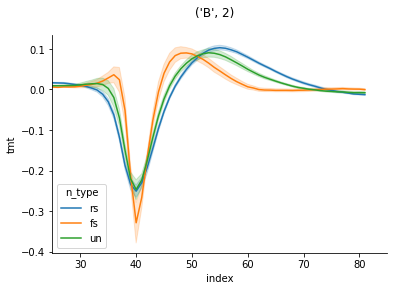

In [27]:
#Plot the average waveforms of FS/RS neurons
psth_df = psth_df_fam_hpc[psth_df_fam_hpc['vis_res']==0]
df_tmt = df_tmt_fam_hpc
for t, tt in df_tmt.groupby(['group','stim_id']):
    #for visually responsive true unit only
    group = t[0]
    stim_id = t[1]
    psth_df_tmp = psth_df[(psth_df['group']==group) & (psth_df['stim_id']==stim_id)]
    ls_cuid = psth_df_tmp.cuid.unique()
    df_tmt_final = tt[tt['cuid'].isin(ls_cuid)]
    
    tmp = df_tmt_final.reset_index()
    sns.lineplot(
        data=tmp,
        x='index',
        y='tmt',
        hue='n_type',
        hue_order=['rs','fs','un']
        #units='cuid'
    )
    
    sns.despine()
    plt.xlim(25,85)
    #plt.ylim(-6.5,3)
    plt.suptitle(f'{t}')
    #plt.savefig(f"U:/Data_Analysis/yin268/LemonPy analysis/MZ_FXbehavior_data/figure/strong/hpc_{t}_rsfs_waveform.pdf", transparent=True)
    plt.show()

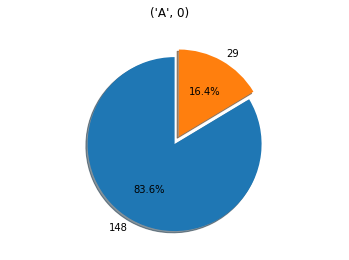

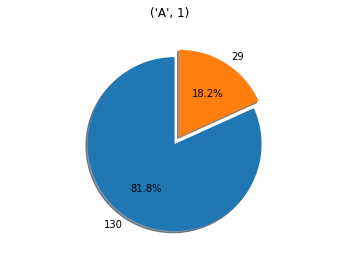

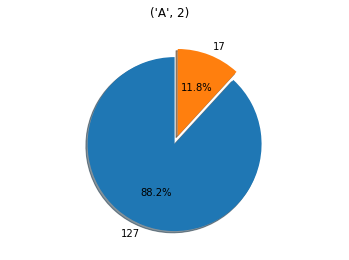

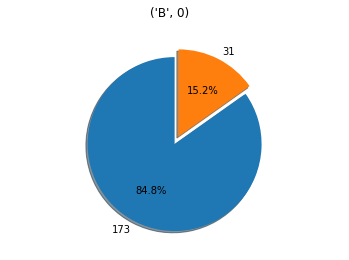

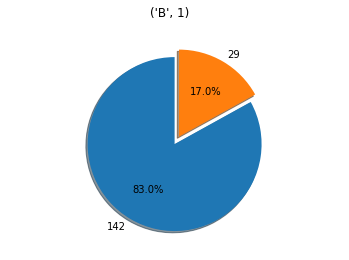

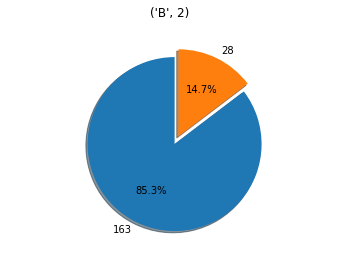

In [28]:
#pie plot for FS/RS neurons
psth_df = psth_df_fam_hpc[psth_df_fam_hpc['vis_res']==0]
df_tmt = df_tmt_fam_hpc

for t, tt in df_tmt.groupby(['group','stim_id']):
    #for visually responsive true unit only
    group = t[0]
    stim_id = t[1]
    psth_df_tmp = psth_df[(psth_df['group']==group) & (psth_df['stim_id']==stim_id)]
    ls_cuid = psth_df_tmp.cuid.unique()
    df_tmt_final = tt[tt['cuid'].isin(ls_cuid)]

    count = len(df_tmt_final.cuid.unique())
    count_fs = len(df_tmt_final[(df_tmt_final.n_type=='fs')].cuid.unique())
    percent_fs = (count_fs / count) * 100
    count_rs = len(df_tmt_final[(df_tmt_final.n_type=='rs')].cuid.unique())
    percent_rs = (count_rs / count) * 100

    labels = str(count_rs), str(count_fs)
    
    sizes = [percent_rs, percent_fs]
    explode = (0, 0.1)  #0.1 if you want to "pop out" one of the pieces
    plt.axis('equal')
    plt.pie(sizes, explode=explode, labels=labels, 
            autopct='%1.1f%%', shadow=True, startangle=90)
    plt.suptitle(f'{t}')
    #plt.savefig(f"U:/Data_Analysis/yin268/LemonPy analysis/MZ_FXbehavior_data/figure/strong/hpc_{t}_rsfs_piechart.pdf", transparent=True)
    plt.show()


In [29]:
psth_df = psth_df_fam_hpc[psth_df_fam_hpc['vis_res']==0]
df_tmt = df_tmt_fam_hpc

summary = []

for t, tt in df_tmt.groupby(['group','stim_id','et']):
    #for visually responsive true unit only
    group = t[0]
    stim_id = t[1]
    et = t[2]
    psth_df_tmp = psth_df[(psth_df['group']==group) & (psth_df['stim_id']==stim_id)& (psth_df['et']==et)]
    ls_cuid = psth_df_tmp.cuid.unique()
    df_tmt_final = tt[tt['cuid'].isin(ls_cuid)]

    count = len(df_tmt_final.cuid.unique())
    count_fs = len(df_tmt_final[(df_tmt_final.n_type=='fs')].cuid.unique())
    percent_fs = (count_fs / count) * 100
    count_rs = len(df_tmt_final[(df_tmt_final.n_type=='rs')].cuid.unique())
    percent_rs = (count_rs / count) * 100
    
    summary.append({
        'group': group,
        'et':et,
        'stim_id': stim_id,
        'count_total': count_fs+count_rs,
        'count_fs': count_fs,
        'count_rs': count_rs,
        'percent_fs': percent_fs,
        'percent_rs': percent_rs
    })
    df_summary = pd.DataFrame(summary)



In [30]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm
    
df_summary = df_summary.dropna(subset=['percent_fs'])  # Drop NaN rows if any

# LMM model: percent_fs ~ group + (1|et)
model = mixedlm("percent_fs ~ group", df_summary, groups=df_summary["stim_id"])
result = model.fit()
print(result.summary())


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: percent_fs
No. Observations: 54      Method:             REML      
No. Groups:       3       Scale:              25.1054   
Min. group size:  18      Log-Likelihood:     -161.9263 
Max. group size:  18      Converged:          Yes       
Mean group size:  18.0                                  
--------------------------------------------------------
              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------
Intercept     11.956    1.305  9.162 0.000  9.398 14.514
group[T.B]    -0.807    1.372 -0.588 0.556 -3.496  1.882
Group Var      2.598    0.813                           



In [31]:
for stim_id in df_summary.stim_id.unique():
    df_each=df_summary[df_summary['stim_id']==stim_id]
    stat, p_normal = shapiro(df_each.percent_fs)
    print(f"Shapiro-Wilk test p = {p_normal:.4f}")
    
    # if p_normal > 0.05:
    #     print("percentage are normal → use t-test")
    # else:
    #     print("percentage are not normal → use Mann–Whitney U")

Shapiro-Wilk test p = 0.2576
Shapiro-Wilk test p = 0.8656
Shapiro-Wilk test p = 0.0855


In [32]:
for stim_id in df_summary.stim_id.unique():
    df_each=df_summary[df_summary['stim_id']==stim_id]
    group_names = df_each['group'].unique()
    g1, g2 = group_names
    data1 = df_each[df_each['group'] == g1]['percent_fs']
    data2 = df_each[df_each['group'] == g2]['percent_fs']
    
    stat, pval = mannwhitneyu(data1, data2, alternative='two-sided')
    print(f"\nMann–Whitney U between {g1} and {g2} for {stim_id}: U = {stat:.3f}, p = {pval:.4f}")



Mann–Whitney U between A and B for 0: U = 47.500, p = 0.5329

Mann–Whitney U between A and B for 1: U = 52.500, p = 0.2861

Mann–Whitney U between A and B for 2: U = 34.000, p = 0.6242


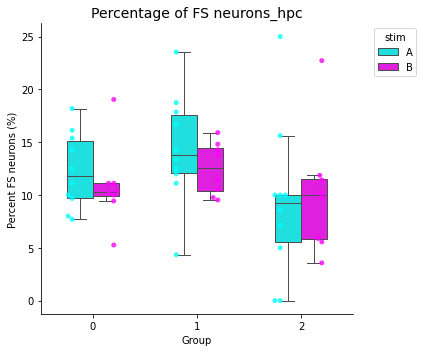

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

palette = {"A": "cyan", "B": "magenta"}

plt.figure(figsize=(6,5))
sns.boxplot(data=df_summary, x='stim_id', y='percent_fs', hue='group',
            width=0.5, fliersize=0,     palette=palette)
sns.swarmplot(data=df_summary, x='stim_id', y='percent_fs',
              hue='group', dodge=True, size=5, alpha=0.8, palette=palette,legend=False)

plt.title("Percentage of FS neurons_hpc", fontsize=14)
plt.ylabel("Percent FS neurons (%)")
plt.xlabel("Group")
plt.legend(title='stim', bbox_to_anchor=(1.05, 1), loc='upper left')
sns.despine()
plt.tight_layout()
#plt.savefig(f"U:/Data_Analysis/yin268/LemonPy analysis/MZ_FXbehavior_data/figure/strong/hpc_{t}_rsfs_quantification.pdf", transparent=True)
plt.show()


## Save FS/RS dataframe with only units has strong oscillations

In [16]:
cuid_to_type = dict(df_tmt_fam[['cuid', 'n_type']].drop_duplicates('cuid').values)
psth_df_fam_strong['n_type'] = psth_df_fam_strong['cuid'].map(cuid_to_type)
psth_df_fam_strong['situ']='post'

No. of mice:  18
Groups:  ['B' 'A']
Brain regions:  ['none' 'thal' 'v1' 'hippo']


In [28]:
psth_df_fam_strong = unit_kmeans(psth_df_fam_strong, 2, 'vis_res', 50, 70) 

In [29]:
## FS
psth_df_fam_fs=psth_df_fam_strong[psth_df_fam_strong['n_type']=='fs']
final_df_tmt_v1_fs=df_tmt_fam[df_tmt_fam['n_type']=='fs']

psth_df_fam_fs.to_pickle(r"U:\Data_Analysis\yin268\LemonPy analysis\MZ_FXbehavior_data\StrongFS\psth_df.pkl")
final_df_tmt_v1_fs.to_pickle(r"U:\Data_Analysis\yin268\LemonPy analysis\MZ_FXbehavior_data\StrongFS\waveforms_df.pkl")

In [30]:
## RS
psth_df_fam_rs=psth_df_fam_strong[psth_df_fam_strong['n_type']=='rs']
final_df_tmt_v1_rs=df_tmt_fam[df_tmt_fam['n_type']=='rs']

psth_df_fam_rs.to_pickle(r"U:\Data_Analysis\yin268\LemonPy analysis\MZ_FXbehavior_data\StrongRS\psth_df.pkl")
final_df_tmt_v1_rs.to_pickle(r"U:\Data_Analysis\yin268\LemonPy analysis\MZ_FXbehavior_data\StrongRS\waveforms_df.pkl")

## V1 Layer specific analysis

### Map Layers

In [6]:
psth_df_fam_v1=psth_df_fam[psth_df_fam['region'] == 'v1']

In [7]:
psth_df_fam_v1['depth_0']=psth_df_fam_v1['depth']
psth_df_fam_v1['depth']=3000-psth_df_fam_v1['depth_0']

<ipython-input-7-f2e4e8d55ad5>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  psth_df_fam_v1['depth_0']=psth_df_fam_v1['depth']
<ipython-input-7-f2e4e8d55ad5>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  psth_df_fam_v1['depth']=3000-psth_df_fam_v1['depth_0']


In [8]:
psth_df_fam_v1['layer'] = ['0']*psth_df_fam_v1.shape[0]
psth_df_fam_v1['layer'][psth_df_fam_v1['depth']<100] = ['L1&L23'] * len(psth_df_fam_v1['depth']<100)
psth_df_fam_v1['layer'][(psth_df_fam_v1['depth']>=100)&(psth_df_fam_v1['depth']<350)] = ['L1&L23'] * len(psth_df_fam_v1[(psth_df_fam_v1['depth']>=100)&(psth_df_fam_v1['depth']<350)])
psth_df_fam_v1['layer'][(psth_df_fam_v1['depth']>=350)&(psth_df_fam_v1['depth']<600)] = ['L4'] * len(psth_df_fam_v1[(psth_df_fam_v1['depth']>=350)&(psth_df_fam_v1['depth']<600)])
psth_df_fam_v1['layer'][(psth_df_fam_v1['depth']>=600)&(psth_df_fam_v1['depth']<800)] = ['L5'] * len(psth_df_fam_v1[(psth_df_fam_v1['depth']>=600)&(psth_df_fam_v1['depth']<800)])
psth_df_fam_v1['layer'][psth_df_fam_v1['depth']>=800] = ['L6'] * len(psth_df_fam_v1['depth']>=800)

<ipython-input-8-fa3394c98553>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  psth_df_fam_v1['layer'] = ['0']*psth_df_fam_v1.shape[0]
<ipython-input-8-fa3394c98553>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  psth_df_fam_v1['layer'][psth_df_fam_v1['depth']<100] = ['L1&L23'] * len(psth_df_fam_v1['depth']<100)
<ipython-input-8-fa3394c98553>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-v

In [9]:
psth_df_fam_v1 = unit_kmeans(psth_df_fam_v1, 2, 'vis_res', 50, 70) 
psth_df_fam_v1_VR = psth_df_fam_v1[psth_df_fam_v1['vis_res']==0]

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\threadpoolctl.py:1186: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


### Plot layer-specific heatmap

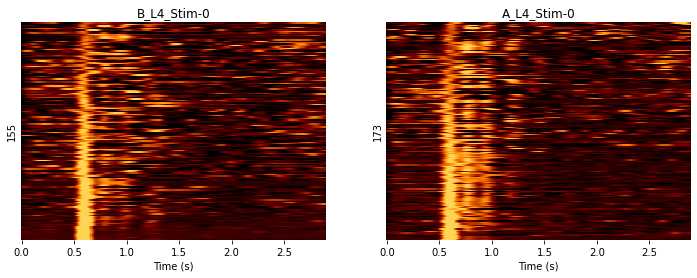

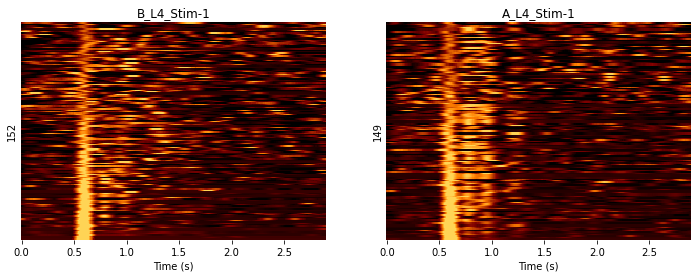

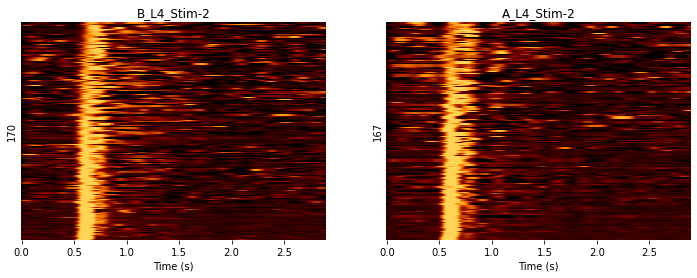

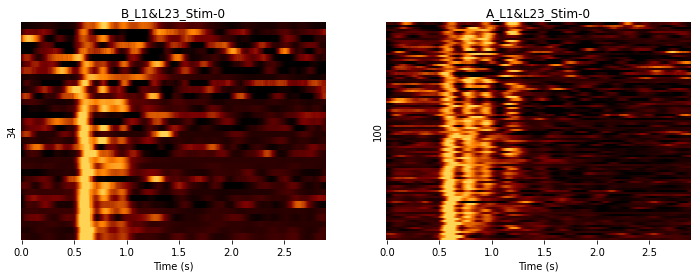

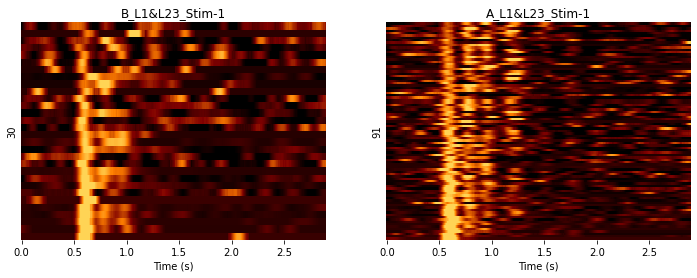

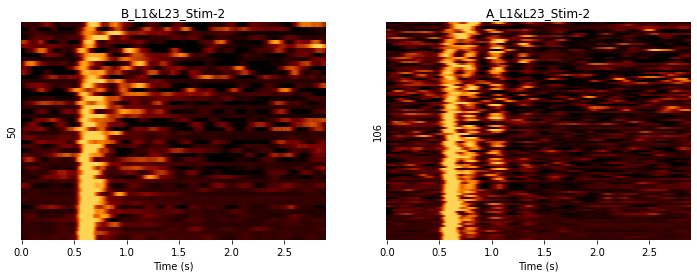

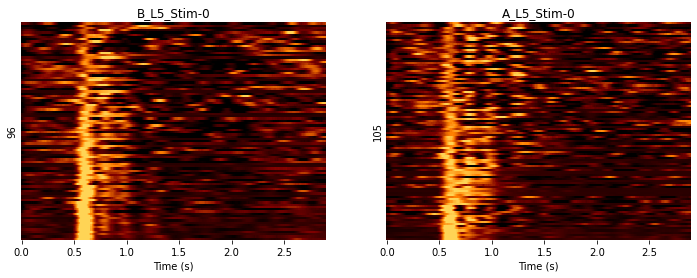

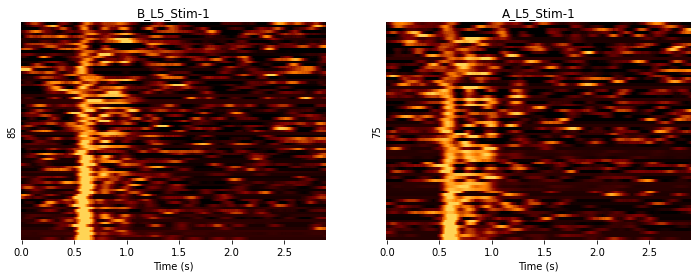

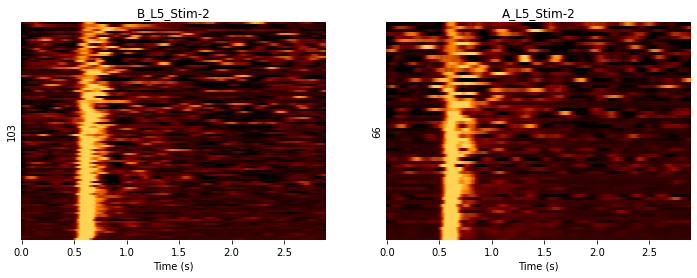

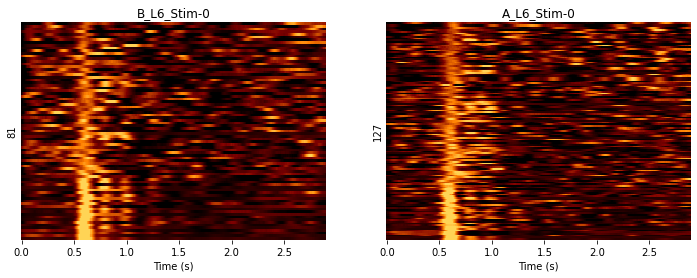

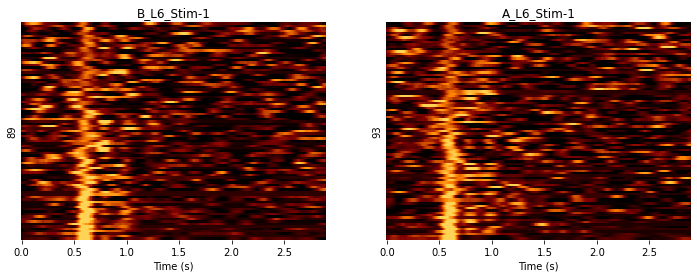

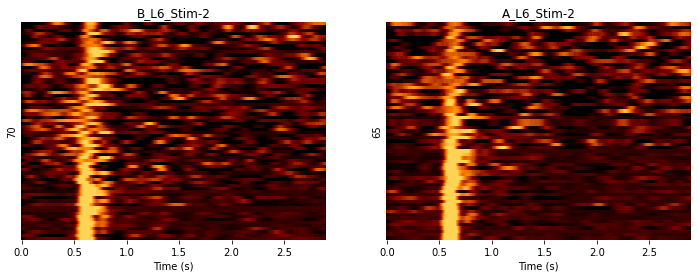

In [9]:
stage = 'post'
v_max, v_min = 3, -1
y_min, y_max = -2, 6
xvalues = np.arange(start=0, stop=3, step=0.5)

V1df_grouped = {}
for layer in psth_df_fam_v1_VR['layer'].unique():
     for group in psth_df_fam_v1_VR.group.unique():
            for stim in psth_df_fam_v1_VR.stim_id.unique():
                psth_df_layer = psth_df_fam_v1_VR[(psth_df_fam_v1_VR['layer'] == layer)& (psth_df_fam_v1_VR['stim_id'] == stim) & (psth_df_fam_v1_VR['group'] == group)]
            
                V1df_group_temp = psth_df_layer.pivot(
                    index='cuid', columns='times', values='zscore'
                )
            
                V1df_group = V1df_group_temp.values[
                    np.argsort(np.mean(
                        V1df_group_temp.values[:, int(0.5*100):int(0.7*100)], axis=1
                    ))
                ]  ########## [MODIFY]: 50 and 70 ########
            
                cuid_count = psth_df_layer.cuid.nunique()
            
                V1df_grouped.setdefault(group, {})[f'{layer}_{stim}_values'] = V1df_group
                V1df_grouped.setdefault(group,{})[f'{layer}_{stim}_cuid_count'] = cuid_count #Mowen Changed the naming of cuid_count to include stim_id

# plotting
for layer in psth_df_fam_v1_VR['layer'].unique():
    for stim in psth_df_fam_v1_VR.stim_id.unique():
        f, axs = plt.subplots(1, 2, sharex='col', figsize=(12,4))
        
        for j, (group, V1df_group) in enumerate(V1df_grouped.items()):
            sns.heatmap(
                V1df_group[f'{layer}_{stim}_values'], 
                cmap='afmhot', xticklabels=50, yticklabels=False, 
                cbar=False,
                vmax=v_max, center=2, vmin=v_min, robust=True, ax=axs[j]
            )
            axs[j].set_ylabel(str(V1df_group[f'{layer}_{stim}_cuid_count']))
            axs[j].set_xticklabels('')
            axs[j].set_xlim(0, (3 - 0.1) * 100)
            axs[j].set_title(f'{group}_{layer}_Stim-{stim}')
            axs[j].set_xticklabels(xvalues, rotation=0)
            axs[j].set_xlabel('Time (s)')

        f.subplots_adjust(hspace=0.1)
        plt.savefig(f"U:/Data_Analysis/yin268/LemonPy analysis/MZ_FXbehavior_data/figure/Layer specific/Heatmap_{layer}_Stim-{stim}.pdf", transparent=True)
        plt.show()

In [10]:
group_palette={'A':'cyan','B':'magenta'}

0


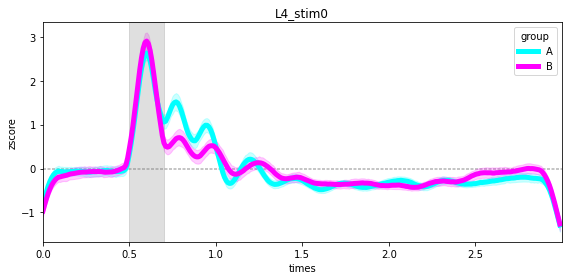

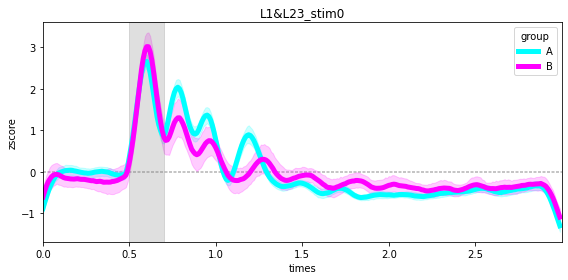

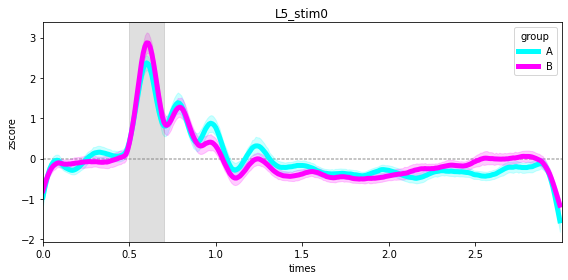

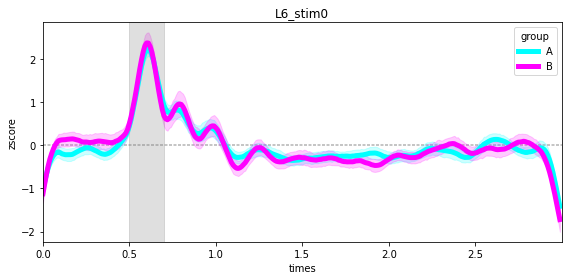

1


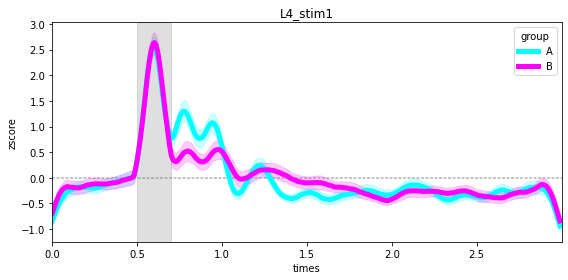

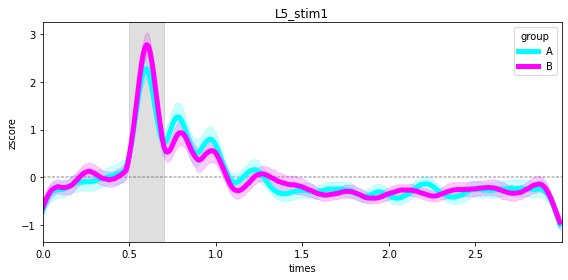

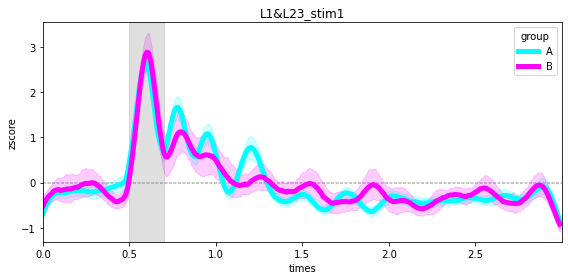

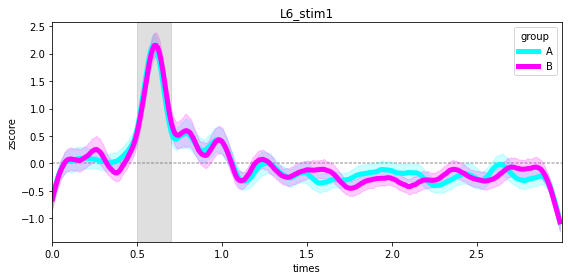

2


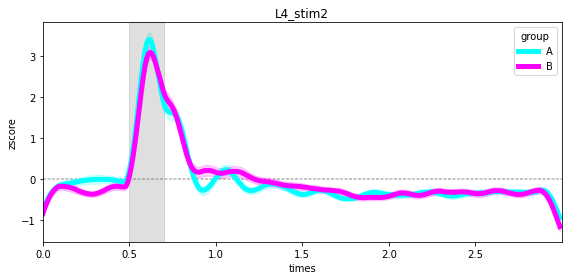

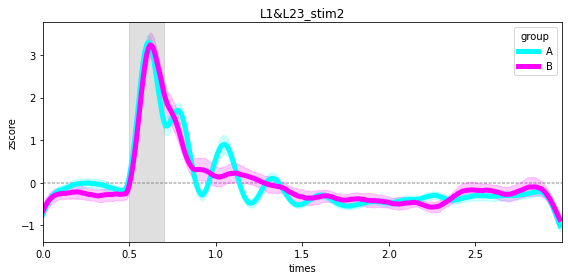

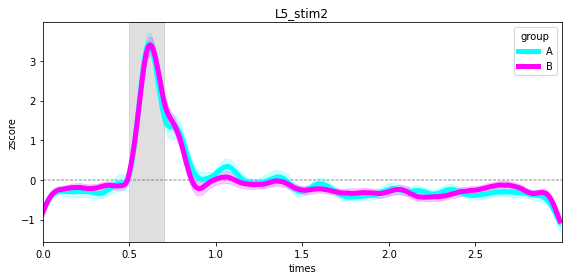

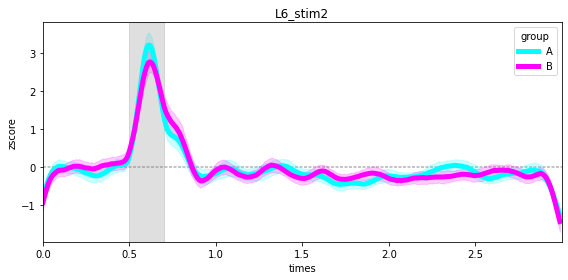

In [12]:
df = psth_df_fam_v1_VR
for stim in df["stim_id"].unique():
    print(stim)
    psth_df_stim = df[df["stim_id"] == stim]
    for layer in psth_df_stim["layer"].unique():
        psth_df_stim_layer = psth_df_stim[psth_df_stim['layer']==layer]
        fig, ax = plt.subplots(figsize=(8, 4))
    
        sns.lineplot(
            x='times', y='zscore', hue='group', hue_order=['A','B'],
            data=psth_df_stim_layer, ax=ax,palette=group_palette, linewidth=5
        )
    
        ax.axhline(y=0, color=".7", dashes=(2, 1), zorder=0)
        ax.axvspan(0.5, 0.7, color='grey', alpha=0.25)
    
        ax.set_ylabel("zscore")
        ax.set_title(f"{layer}_stim{stim}")
        #ax.set_ylim(-1.5, 3.5)
        ax.set_xlim(0, 3)
        ax.set_xticks(np.arange(0, 3, 0.5))
    
        plt.tight_layout()
        #plt.savefig(f"U:/Data_Analysis/yin268/LemonPy analysis/MZ_FXbehavior_data/figure/Layer specific/zscore_{layer}_Stim-{stim}.pdf", transparent=True)
        plt.show()

### Layer-specific Quantifications: peak number and FFT

In [10]:
from LemonPy.Units.detect_peaks import detect_peaks
from LemonPy.Units import mz_ephys_unit_analysis as mz_ena
from LemonPy.Units import mz_unit_dur_freq as mz_udf
from LemonPy.utils_vmk import generate_2_pair_combinations
from scipy import stats

def get_unit_df(psth_df):
    print("No. of mice: ", psth_df.et.nunique())
    print("Groups: ", psth_df.group.unique())
    print("Brain regions: ",psth_df.region.unique())

    V1_all_groups_situ = psth_df
        
    grouped_dur_freq = {}
    for group in V1_all_groups_situ.group.unique():
        for i in range(V1_all_groups_situ.stim_id.nunique()):
            temp_arr = V1_all_groups_situ[(V1_all_groups_situ['group'] == group) & (V1_all_groups_situ['stim_id'] == V1_all_groups_situ.stim_id.unique()[i])] 
            duration = []
            ind = []
            unit_region = []
            layer=[]
            et=[]
            for unit, df in temp_arr.groupby('cuid'):
                # yy = np.array(df.pivot(index='cuid', columns='times', values='zscore'))
                yy = np.array(df.zscore)
                dur, peak_ind = mz_udf._duration_peaks_unit(yy)
                duration.append(dur)
                ind.append(peak_ind)
                unit_region.append(df.region.unique()[0])
                layer.append(df.layer.unique()[0])
                et.append(df.et.unique()[0])
            grouped_dur_freq.setdefault(group, {})[f'stim{V1_all_groups_situ.stim_id.unique()[i]}_values'] = {'duration': duration, 'ind': ind, 'region': unit_region,'layer':layer,'et':et}

        all_dur_df = {}
        n_stim = len(next(iter(grouped_dur_freq.values())))

    for stim in range(n_stim):
        for i, (group, stim_grouped_data) in enumerate(grouped_dur_freq.items()):
            data_dur = stim_grouped_data[f'stim{V1_all_groups_situ.stim_id.unique()[stim]}_values']['duration']
            data_ind = stim_grouped_data[f'stim{V1_all_groups_situ.stim_id.unique()[stim]}_values']['ind']
            all_brain_regions = stim_grouped_data[f'stim{V1_all_groups_situ.stim_id.unique()[stim]}_values']['region']
            data_layer = stim_grouped_data[f'stim{V1_all_groups_situ.stim_id.unique()[stim]}_values']['layer']
            et = stim_grouped_data[f'stim{V1_all_groups_situ.stim_id.unique()[stim]}_values']['et']
            mean_freq =  [1/np.diff(i)*100 + 1 for i in stim_grouped_data[f"stim{V1_all_groups_situ.stim_id.unique()[stim]}_values"]['ind']]
            all_dur_df.setdefault(f'stim{V1_all_groups_situ.stim_id.unique()[stim]}', []).append(pd.DataFrame(tuple(zip(data_dur, mean_freq, data_ind, ([group]*len(data_dur)), ([V1_all_groups_situ.stim_id.unique()[stim]]*len(data_dur)), all_brain_regions,data_layer,et)), columns=['dur', 'freq', 'ind','group','stim', 'region','layer','et']))
        temp_df = pd.concat(all_dur_df[f'stim{V1_all_groups_situ.stim_id.unique()[stim]}'])
        temp_df = temp_df[~temp_df.dur.isna()]
        temp_df['up_cyc'] = temp_df.freq.str[1] # [MODIFY]
        temp_df['mean_freq'] = temp_df.freq.apply(lambda x: np.mean(x))
        # temp_df = temp_df[~temp_df.up_cyc.isna()]
        all_dur_df[f'stim{V1_all_groups_situ.stim_id.unique()[stim]}'] = temp_df

    all_dur_df = pd.concat(all_dur_df.values(), ignore_index=True)

    return all_dur_df#, brain_region 

In [11]:
unit_peak_df = get_unit_df(psth_df_fam_v1_VR)

No. of mice:  18
Groups:  ['B' 'A']
Brain regions:  ['v1']


C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


In [22]:
unit_peak_df['peak_num'] = unit_peak_df['ind'].apply(len)
unit_peak_df=unit_peak_df[unit_peak_df['stim']!=1]

In [23]:
import statsmodels.formula.api as smf
#unit_peak_df=unit_peak_df[unit_peak_df['stim']!=1]

results = {}

for layer, temp_df in unit_peak_df.groupby('layer'):
    print(f"\n=== Layer: {layer} ===")
    
    # Drop NaNs
    df = temp_df.dropna(subset=['peak_num']).copy()
    
    df['group'] = df['group'].astype('category')
    df['stim'] = df['stim'].astype('category')
    
    # Fit LMM: random intercept per unit
    model = smf.mixedlm(
        "peak_num ~ C(group) * C(stim)",
        data=df,
        groups=df['et']
    )
    
    fit = model.fit()
    
    print(fit.summary(), "\n")
    results[layer] = fit



=== Layer: L1&L23 ===
                Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     peak_num 
No. Observations:       254         Method:                 REML     
No. Groups:             14          Scale:                  0.5520   
Min. group size:        1           Log-Likelihood:         -297.2739
Max. group size:        41          Converged:              Yes      
Mean group size:        18.1                                         
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                   2.536    0.156 16.288 0.000  2.231  2.842
C(group)[T.B]              -0.556    0.269 -2.064 0.039 -1.084 -0.028
C(stim)[T.2]               -0.544    0.111 -4.921 0.000 -0.761 -0.327
C(group)[T.B]:C(stim)[T.2]  0.079    0.213  0.372 0.710 -0.339  0.498
Group Var    

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\statsmodels\regression\mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2

                Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     peak_num 
No. Observations:       248         Method:                 REML     
No. Groups:             18          Scale:                  0.4962   
Min. group size:        3           Log-Likelihood:         -280.5694
Max. group size:        38          Converged:              No       
Mean group size:        13.8                                         
---------------------------------------------------------------------
                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------
Intercept                   1.655    0.145 11.435 0.000  1.371  1.939
C(group)[T.B]               0.033    0.225  0.149 0.882 -0.408  0.475
C(stim)[T.2]               -0.454    0.125 -3.617 0.000 -0.699 -0.208
C(group)[T.B]:C(stim)[T.2]  0.041    0.190  0.213 0.831 -0.333  0.414
Group Var                   0.148   

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\statsmodels\base\model.py:604: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\statsmodels\regression\mixed_linear_model.py:2206: ConvergenceWarning: MixedLM optimization failed, trying a different optimizer may help.
  warnings.warn(msg, ConvergenceWarning)
C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\statsmodels\regression\mixed_linear_model.py:2218: ConvergenceWarning: Gradient optimization failed, |grad| = 7.186826
  warnings.warn(msg, ConvergenceWarning)


In [30]:
#stats for peak inds
from scipy.stats import tukey_hsd

for (stim,layer), temp_stim in unit_peak_df.groupby(['stim','layer']):
    print('Stim',stim)
    print(layer)
    for g1, g2 in generate_2_pair_combinations(list(temp_stim.group.unique())):
        print(f'Mean of {g1}: {temp_stim[temp_stim.group==g1].peak_num.mean()}')
        print(f'Mean of {g2}: {temp_stim[temp_stim.group==g2].peak_num.mean()}')
        g1_units = len(temp_stim[temp_stim.group == g1])
        g2_units = len(temp_stim[temp_stim.group == g2])
        print(f'{g1} units: {g1_units} --- {g2} units: {g2_units}')
        
        result_hsd = tukey_hsd(temp_stim[temp_stim.group==g1].peak_num.dropna(), temp_stim[temp_stim.group==g2].peak_num.dropna())
        print(result_hsd.pvalue)

Stim 0
L1&L23
Mean of B: 1.9642857142857142
Mean of A: 2.5824175824175826
B units: 28 --- A units: 91
[[1.         0.00192992]
 [0.00192992 1.        ]]
Stim 0
L4
Mean of B: 1.7
Mean of A: 2.267175572519084
B units: 120 --- A units: 131
[[1.00000000e+00 1.09408266e-06]
 [1.09408266e-06 1.00000000e+00]]
Stim 0
L5
Mean of B: 1.705128205128205
Mean of A: 2.231707317073171
B units: 78 --- A units: 82
[[1.00000000e+00 1.22001681e-04]
 [1.22001681e-04 1.00000000e+00]]
Stim 0
L6
Mean of B: 1.8363636363636364
Mean of A: 1.7282608695652173
B units: 55 --- A units: 92
[[1.         0.47506204]
 [0.47506204 1.        ]]
Stim 2
L1&L23
Mean of B: 1.5
Mean of A: 2.086021505376344
B units: 42 --- A units: 93
[[1.00000000e+00 4.29834337e-05]
 [4.29834337e-05 1.00000000e+00]]
Stim 2
L4
Mean of B: 1.5954198473282444
Mean of A: 1.618705035971223
B units: 131 --- A units: 139
[[1.         0.77738415]
 [0.77738415 1.        ]]
Stim 2
L5
Mean of B: 1.434782608695652
Mean of A: 1.6346153846153846
B units: 92 

In [28]:
#stats for peak inds

for (group,layer), temp_stim in unit_peak_df.groupby(['group','layer']):
    print('group',group)
    print(layer)
    for g1, g2 in generate_2_pair_combinations(list(temp_stim.stim.unique())):
        print(f'\nMean of {g1}: {temp_stim[temp_stim.stim==g1].peak_num.mean()}')
        print(f'Mean of {g2}: {temp_stim[temp_stim.stim==g2].peak_num.mean()}')
        g1_units = len(temp_stim[temp_stim.stim == g1])
        g2_units = len(temp_stim[temp_stim.stim == g2])
        print(f'{g1} units: {g1_units} --- {g2} units: {g2_units}')
        
        result_hsd = tukey_hsd(temp_stim[temp_stim.stim==g1].peak_num.dropna(), temp_stim[temp_stim.stim==g2].peak_num.dropna())
        print(result_hsd.pvalue)

group A
L1&L23

Mean of 0: 2.5824175824175826
Mean of 2: 2.086021505376344
0 units: 91 --- 2 units: 93
[[1.00000000e+00 1.49258879e-04]
 [1.49258879e-04 1.00000000e+00]]
group A
L4

Mean of 0: 2.267175572519084
Mean of 2: 1.618705035971223
0 units: 131 --- 2 units: 139
[[1.00000000e+00 1.10631282e-10]
 [1.10631282e-10 1.00000000e+00]]
group A
L5

Mean of 0: 2.231707317073171
Mean of 2: 1.6346153846153846
0 units: 82 --- 2 units: 52
[[1.00000000e+00 2.66409357e-04]
 [2.66409357e-04 1.00000000e+00]]
group A
L6

Mean of 0: 1.7282608695652173
Mean of 2: 1.3888888888888888
0 units: 92 --- 2 units: 54
[[1.         0.01193768]
 [0.01193768 1.        ]]
group B
L1&L23

Mean of 0: 1.9642857142857142
Mean of 2: 1.5
0 units: 28 --- 2 units: 42
[[1.         0.00669059]
 [0.00669059 1.        ]]
group B
L4

Mean of 0: 1.7
Mean of 2: 1.5954198473282444
0 units: 120 --- 2 units: 131
[[1.         0.29482093]
 [0.29482093 1.        ]]
group B
L5

Mean of 0: 1.705128205128205
Mean of 2: 1.43478260869565

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


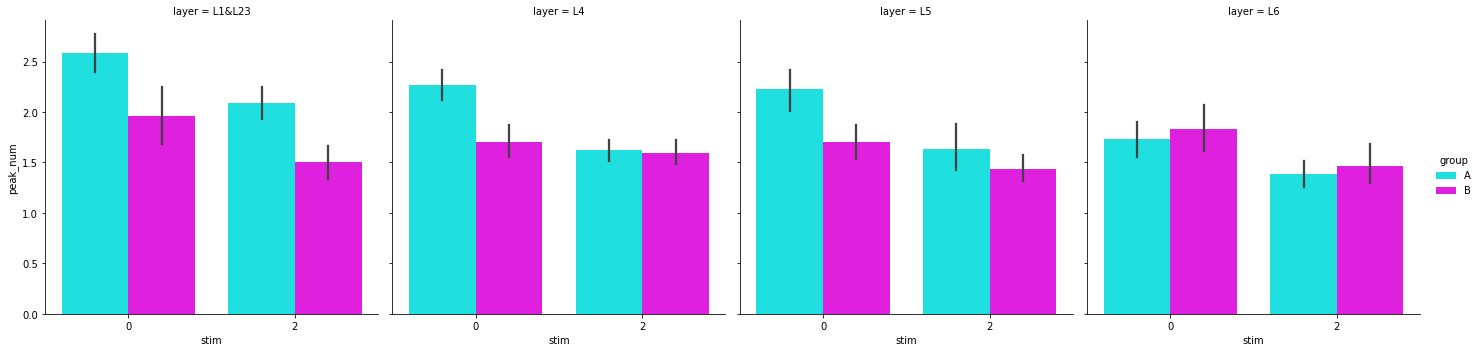

In [72]:
sns.catplot(
    data=unit_peak_df,
    x='stim',
    y='peak_num',
    hue='group',
    hue_order=['A','B'],
    col='layer',
    col_order=['L1&L23','L4','L5','L6'],
    kind='bar',
    palette={'A':'cyan','B':'magenta'}
)

#plt.savefig(f"U:/Data_Analysis/yin268/LemonPy analysis/MZ_FXbehavior_data/figure/Layer specific/peak_number_stats.pdf", transparent=True)
plt.show()

In [77]:
%load_ext autoreload
%autoreload 2
# %load_ext cudf.pandas

json_file = r'U:\Data_Analysis\yin268\LemonPy analysis\MZ_FXbehavior_data\MZ_FXbehavior.json'
units_plotter = UNITS.PlotUnitDF(json_file)

This is a behavior study, behavior data applied.


[0 1 2]
['v1']


C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


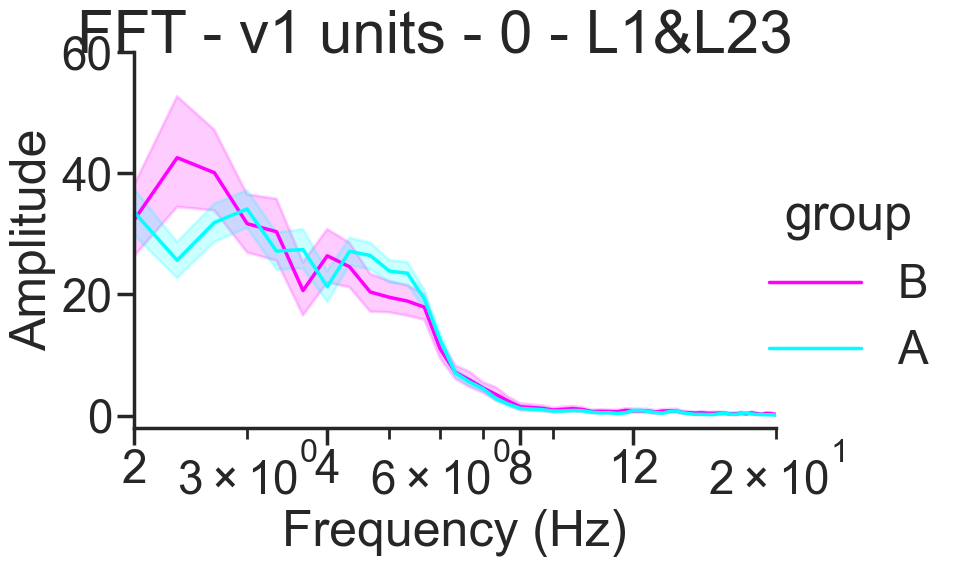

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


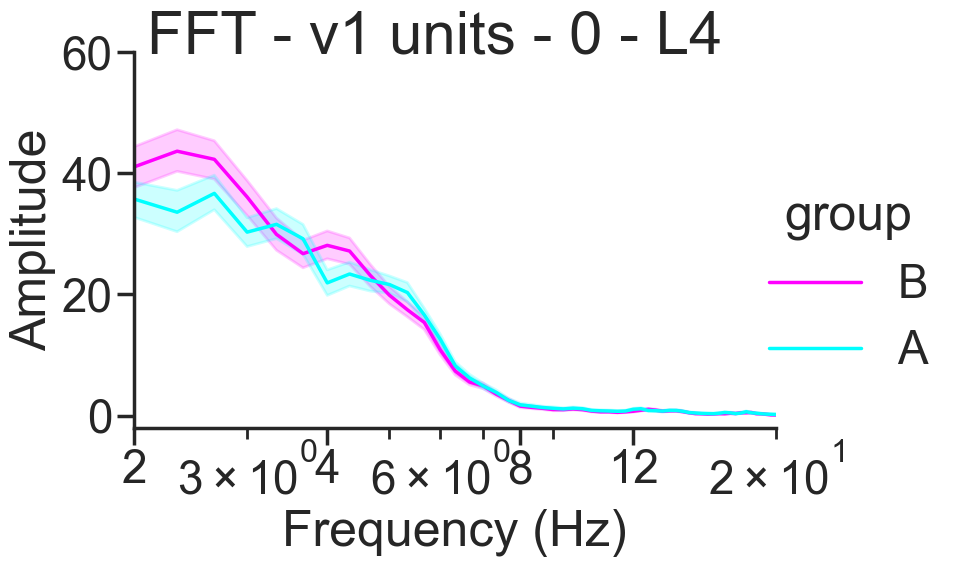

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


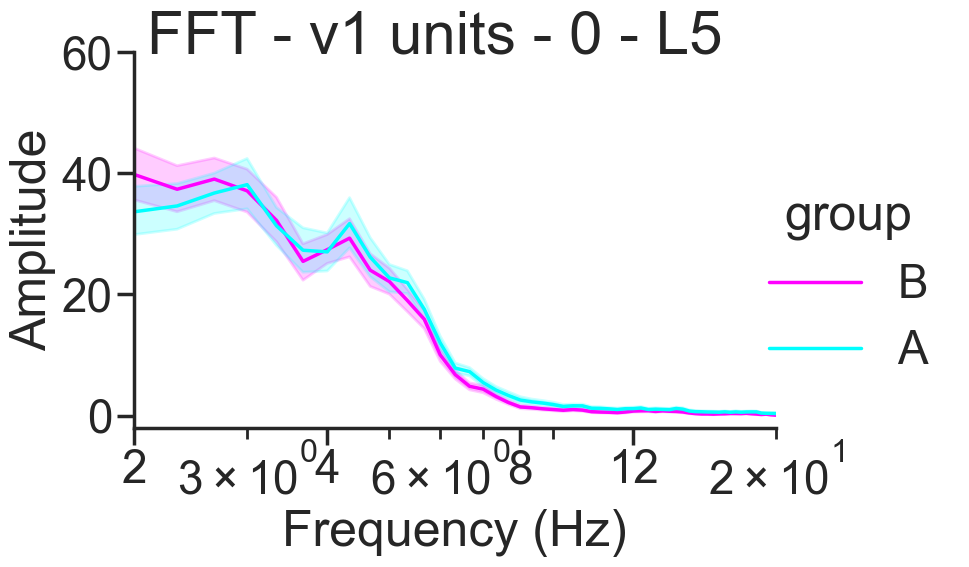

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


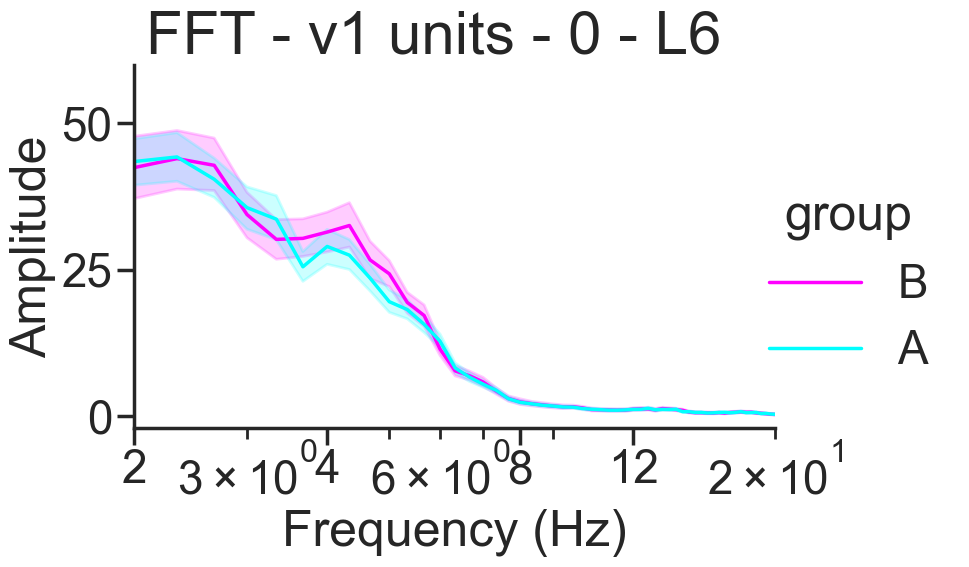

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


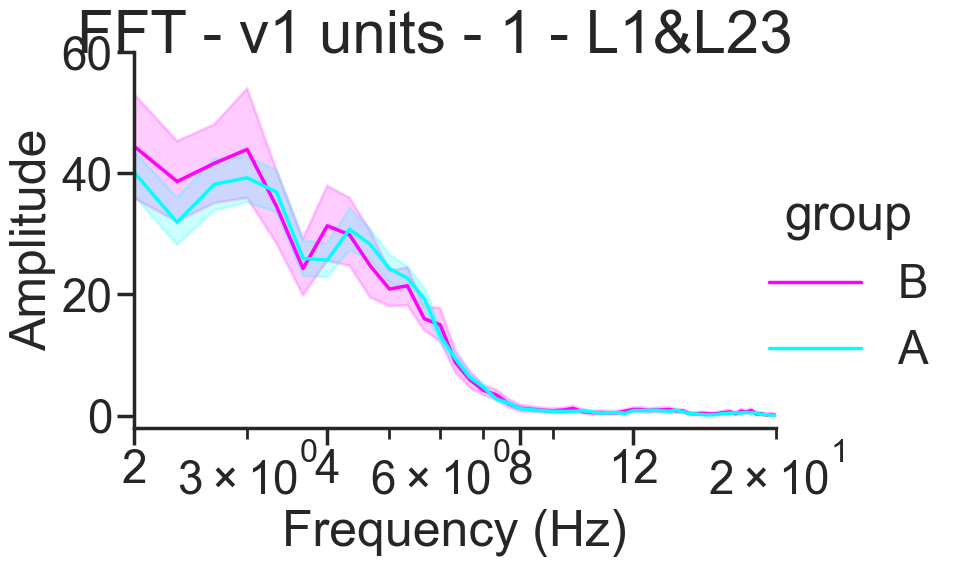

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


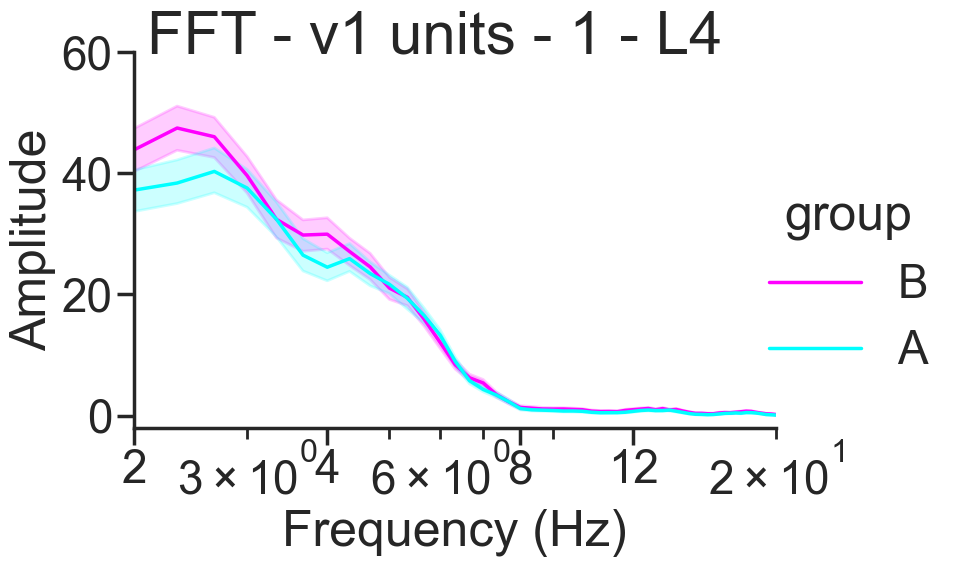

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


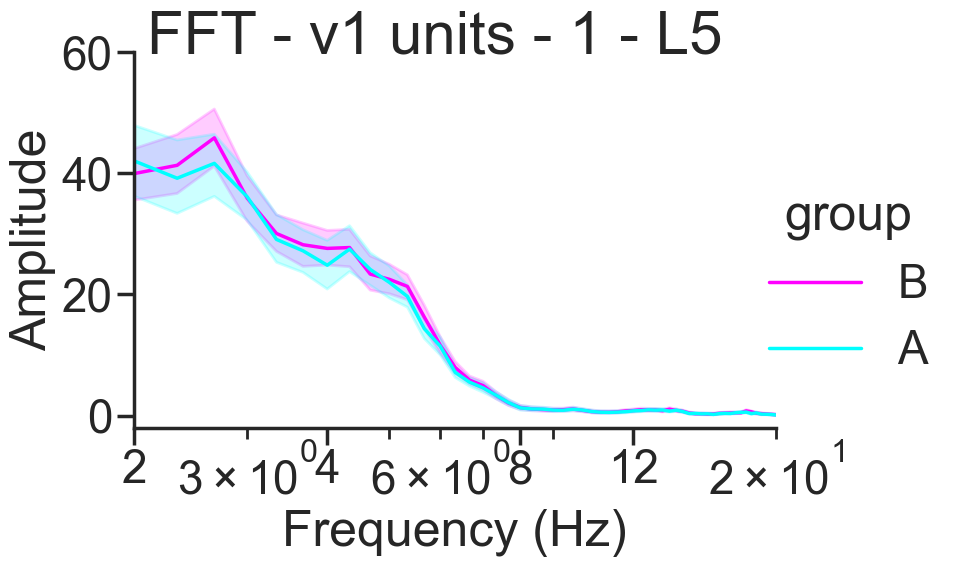

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


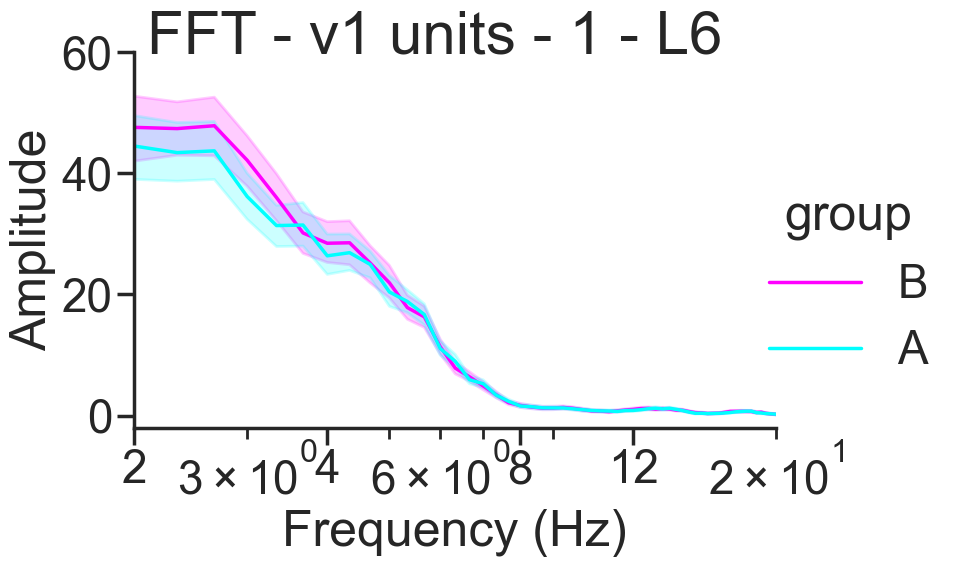

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


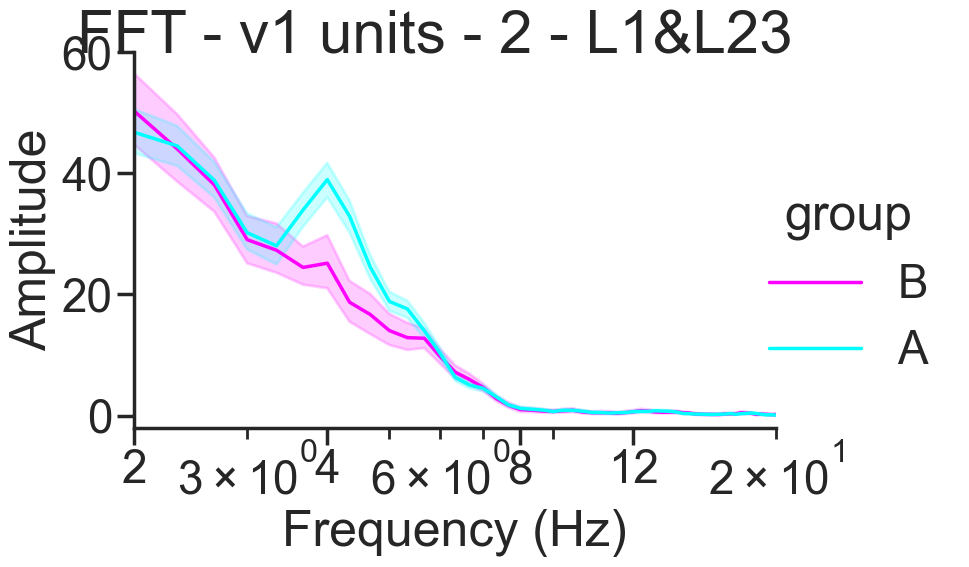

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


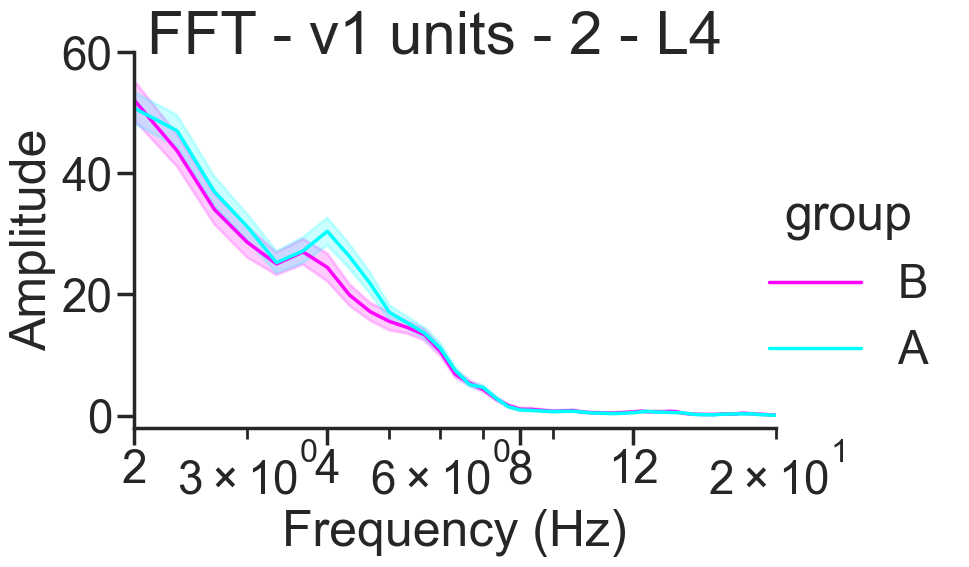

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


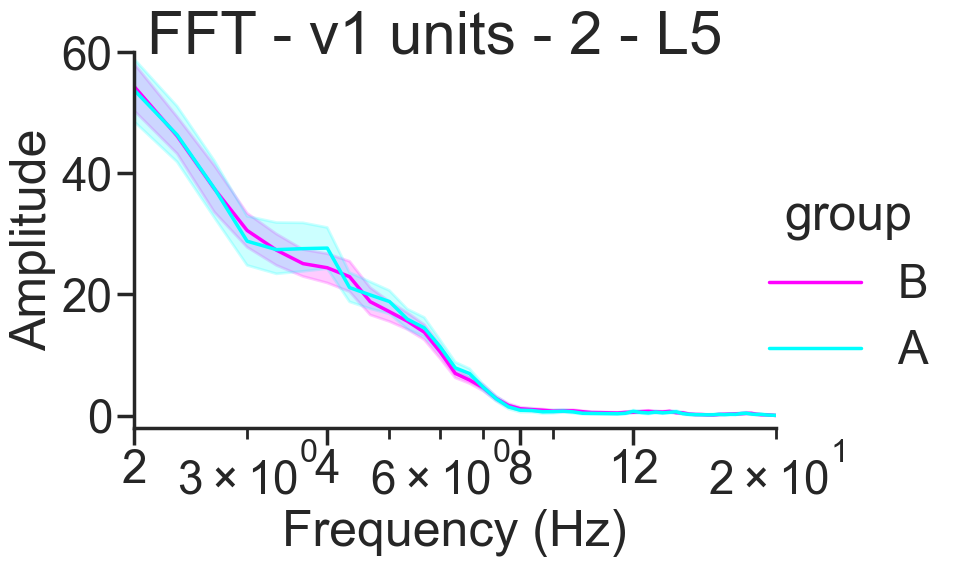

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


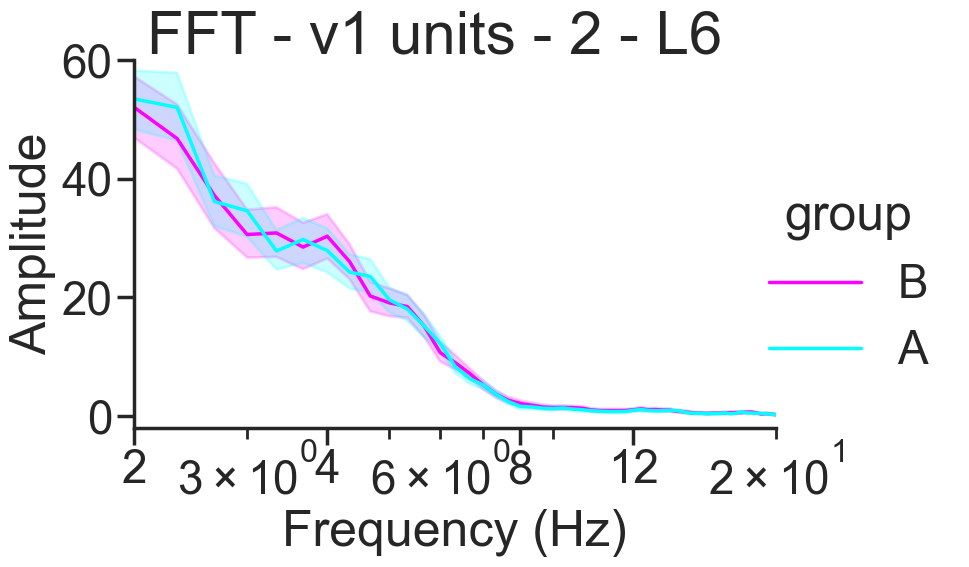

In [111]:
ALLunitsFFT = []
psth_df_visRes_only = psth_df_fam_v1_VR

for c, cc in psth_df_visRes_only.groupby(['stim_id','region','cuid','group','layer']):
    unit1_fft_freq, unit1_fft_amp = units_plotter.get_unit_fft(cc)
    unit1df = pd.DataFrame({'freq':unit1_fft_freq.astype('float'), 
                            'amp':unit1_fft_amp.astype('int32'), 'cuid':c[2], 'region':c[1], 'stim_name':c[0], 'group':c[3],'layer':c[4]})
    ALLunitsFFT.append(unit1df)
    
ALLunitsFFT_df = pd.concat(ALLunitsFFT)
print(ALLunitsFFT_df.stim_name.unique())
print(ALLunitsFFT_df.region.unique())

for t,tt in ALLunitsFFT_df.groupby(['stim_name','region','layer']):
    
    sns.relplot(x='freq', y='amp', estimator='mean', data=tt,
                hue='group', hue_order=list(units_plotter.color_palette.keys()), palette=units_plotter.color_palette,
                kind='line', height=6, aspect=1.5)
    
    plt.suptitle(f'FFT - {t[1]} units - {t[0]} - {t[2]}')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.xscale('log')
    #plt.xticks([2,4,8,12,30,50], labels=[2,4,8,12,30,50])
    plt.xticks([2,4,8,12], labels=[2,4,8,12])
    plt.xlim([2,20])
    plt.ylim([-2,60])
    sns.despine()

    #plt.savefig(f"U:/Data_Analysis/yin268/LemonPy analysis/MZ_FXbehavior_data/figure/Layer specific/FFT - {t[1]} units - {t[0]} - {t[2]}.pdf", transparent=True)
    plt.show()

C:\Users\AChub_Lab\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.8_qbz5n2kfra8p0\LocalCache\local-packages\Python38\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


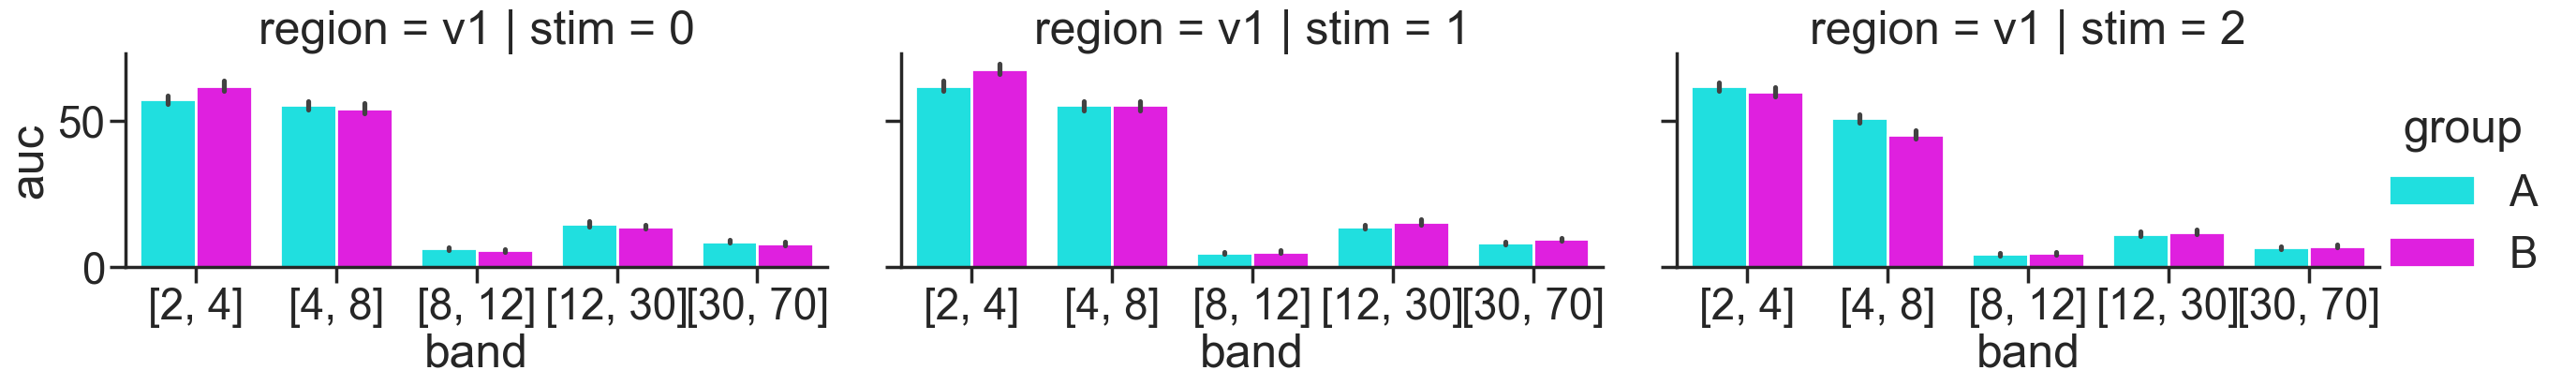

In [112]:
from sklearn.metrics import auc

unit_auc = []
psth_df_visRes_only = psth_df_visRes_only
for unit, df in psth_df_visRes_only.groupby(['cuid', 'stim_id','layer']): # For units responding to different stim_id
    fft_freq, fft_amp = units_plotter.get_unit_fft(df)
    bands = [[2,4],[4,8],[8,12],[12,30],[30,70]]
    auc_val,band_val = [],[]
    for ran in bands:
        lower = fft_freq.searchsorted(ran[0], 'left')
        upper = fft_freq.searchsorted(ran[1], 'right') -1
        val = auc(fft_freq[lower:upper],fft_amp[lower:upper])
        auc_val.append(val)
        band_val.append(str(ran))
    unit_auc.append(pd.DataFrame({'band': band_val, 'auc': auc_val, 'cuid': unit[0], 'layer':unit[2],
                                  'stim': unit[1], 'group': df.group.unique()[0],
                                  'region': df.region.unique()[0], 'et': df.et.unique()[0]}))
all_units_auc = pd.concat(unit_auc)

sns.catplot(data=all_units_auc, x='band', y='auc', kind='bar', 
    hue='group', hue_order=['A','B'], palette=units_plotter.color_palette,
    col='stim', col_order=[0,1,2], 
    row='region',
    height=5, aspect=1.75)
#plt.ylim([0,150])
sns.despine()

#plt.savefig(f"U:/Data_Analysis/yin268/LemonPy analysis/MZ_FXbehavior_data/figure/Layer specific/allStim_AllunitAUC.pdf", transparent=True)

plt.show()

In [107]:
all_units_auc

,band,auc,cuid,layer,stim,group,region,et
0,"[2, 4]",46.339727,CC067431_HP2_437,L6,0,B,v1,CC067431_HP2
1,"[4, 8]",54.077147,CC067431_HP2_437,L6,0,B,v1,CC067431_HP2
2,"[8, 12]",8.879982,CC067431_HP2_437,L6,0,B,v1,CC067431_HP2
3,"[12, 30]",14.479040,CC067431_HP2_437,L6,0,B,v1,CC067431_HP2
4,"[30, 70]",7.449433,CC067431_HP2_437,L6,0,B,v1,CC067431_HP2
...,...,...,...,...,...,...,...,...
0,"[2, 4]",49.105297,CC084621_HP2_719,L1&L23,1,A,v1,CC084621_HP2
1,"[4, 8]",66.477686,CC084621_HP2_719,L1&L23,1,A,v1,CC084621_HP2
2,"[8, 12]",5.876287,CC084621_HP2_719,L1&L23,1,A,v1,CC084621_HP2
3,"[12, 30]",17.436503,CC084621_HP2_719,L1&L23,1,A,v1,CC084621_HP2


In [1]:
#stats for peak inds
from scipy.stats import mannwhitneyu
df_stats = (
    all_units_auc
    .groupby(['stim', 'band','layer'])
    .apply(lambda d: pd.Series({
        'mean_A': d.loc[d.group=='A', 'auc'].mean(),
        'mean_B': d.loc[d.group=='B', 'auc'].mean(),
        'diff': d.loc[d.group=='A', 'auc'].mean() - d.loc[d.group=='B', 'auc'].mean(),
        'ttest_pval': stats.ttest_ind(
            d.loc[d.group=='A', 'auc'],
            d.loc[d.group=='B', 'auc'],
            nan_policy='omit'
        ).pvalue,
        'mwU_pval':mannwhitneyu(d.loc[d.group=='A', 'auc'], d.loc[d.group=='B', 'auc'], alternative='two-sided').pvalue
    }))
    .reset_index()
)
 

NameError: name 'all_units_auc' is not defined

In [ ]:
df_stats